In [1]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filterA = np.array(
    [[0,  1, 0],
     [1, -4, 1],
     [0,  1, 0]])
filterB = np.array(
    [[1,  1, 1],
     [1, -8, 1],
     [1,  1, 1]])

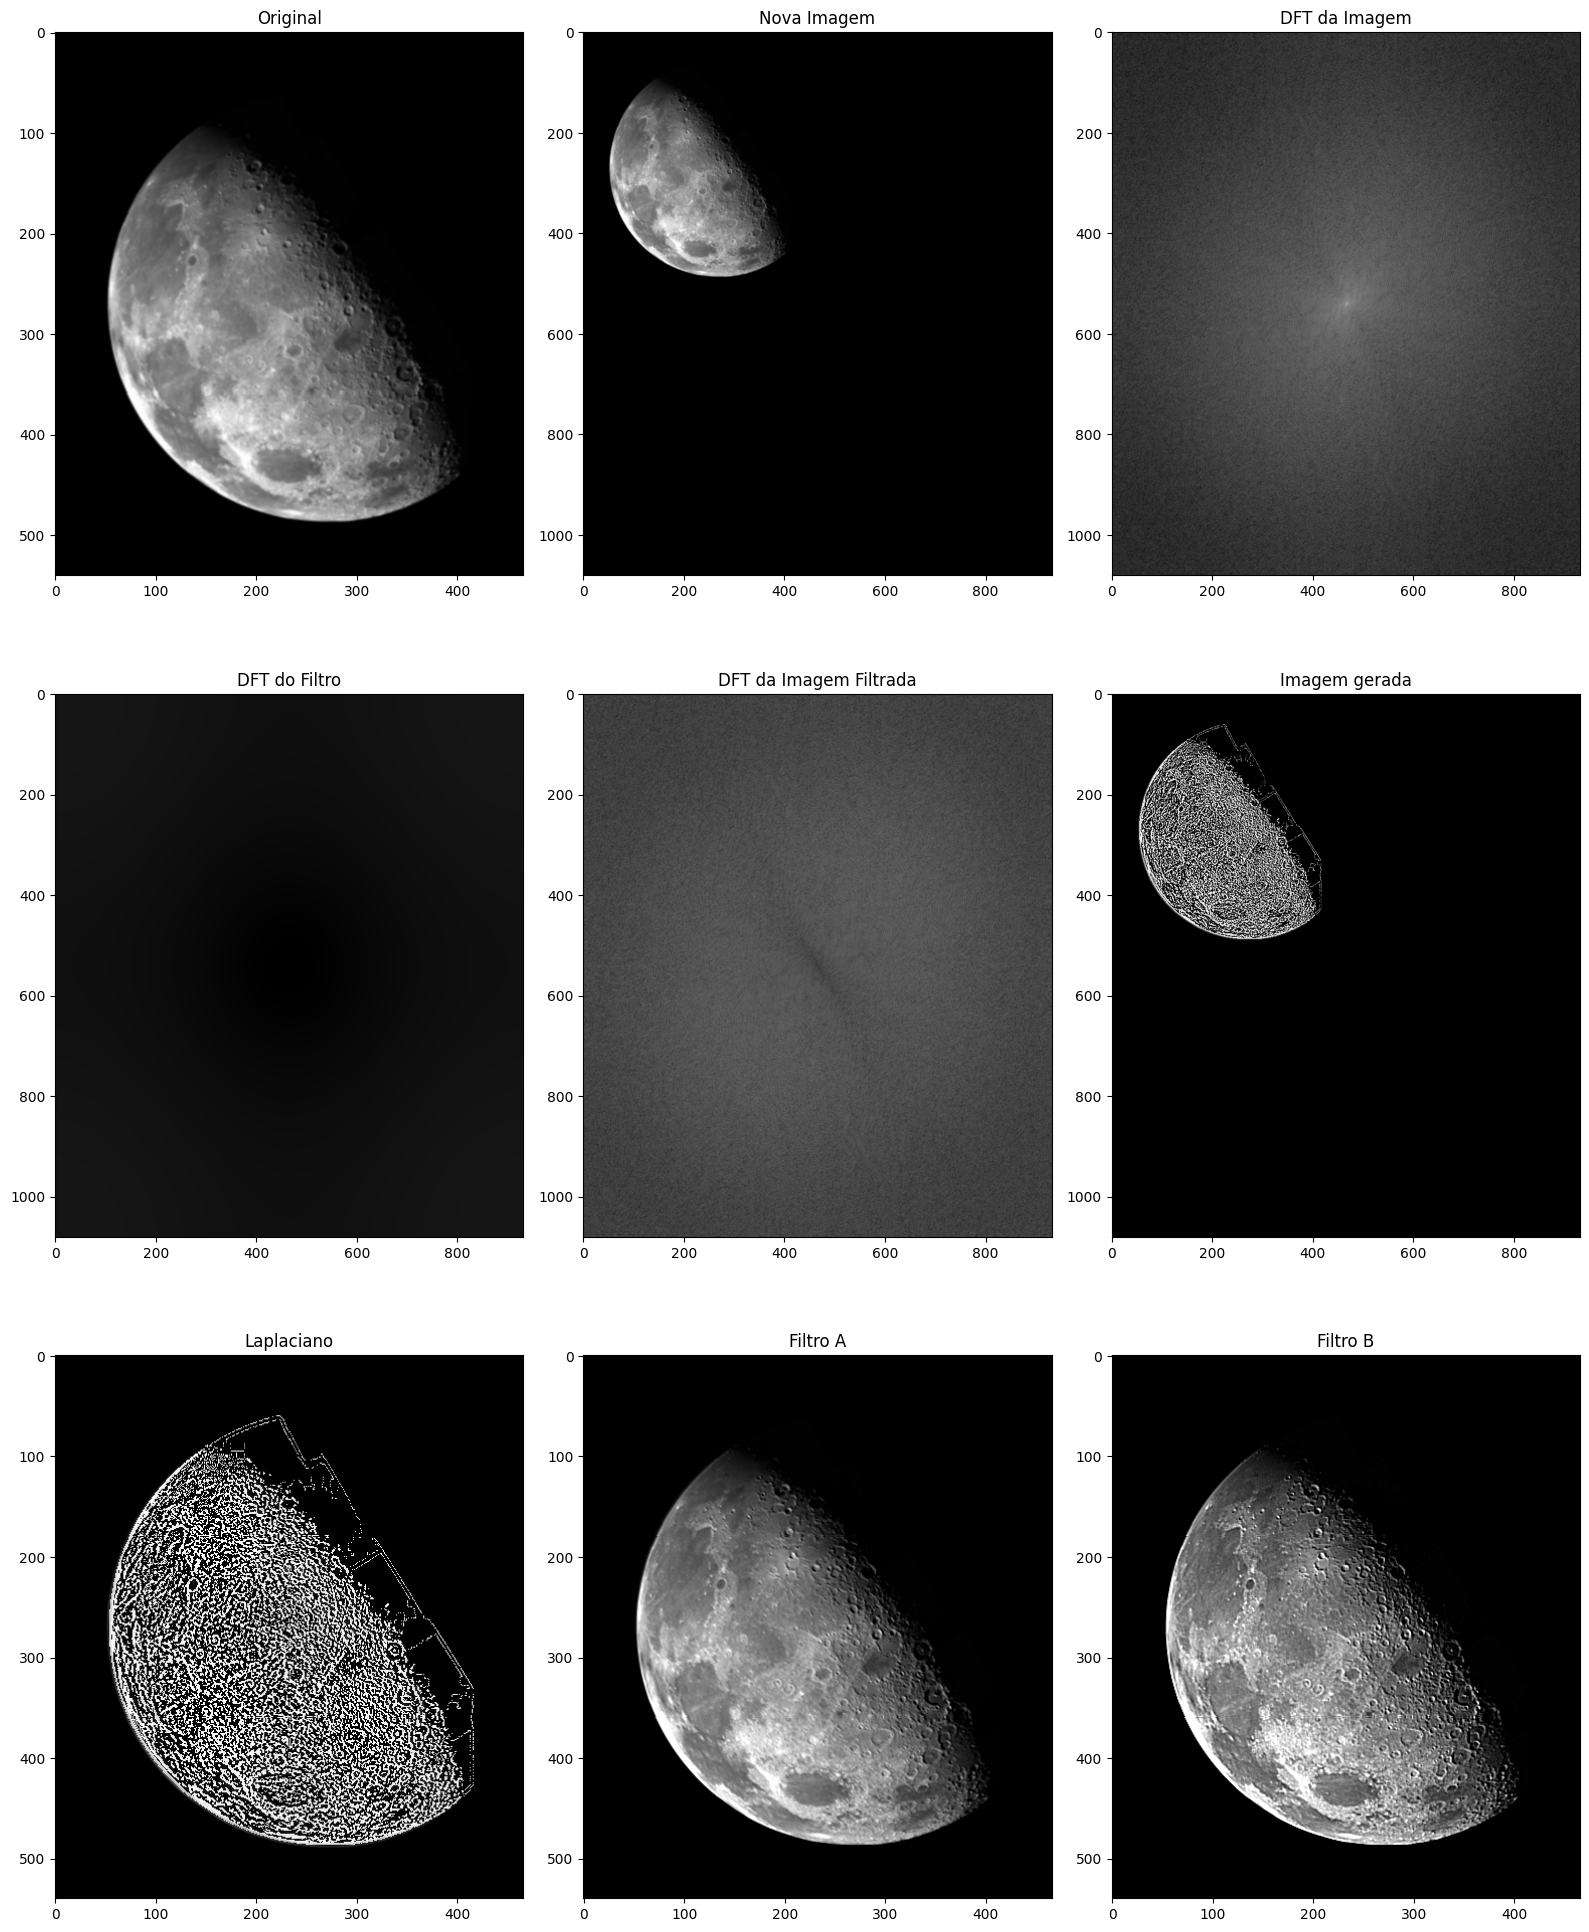

In [3]:
image = cv2.imread("./images/a.tif")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

height = image.shape[0]
width = image.shape[1]

new_height = 2 * height
new_width = 2 * width

new_image = np.zeros((new_height, new_width))
new_image[0:height, 0:width] = image_gray

image_fft = np.fft.fft2(new_image)
image_fft = np.fft.fftshift(image_fft)
output_image_fft = 10 * np.log(np.abs(image_fft) + 1)

# Filtro A

filter = np.zeros((new_height, new_width))
filter[0:3, 0:3] = filterA

filter_fft = np.fft.fft2(filter)
filter_fft = np.fft.fftshift(filter_fft)
output_filter_fft = 10 * np.log(np.abs(filter_fft) + 1)

image_filter_fft = filter_fft * image_fft
output_image_filter_fft = 10 * np.log(np.abs(image_filter_fft) + 1)

image_filter_fft = np.fft.ifftshift(image_filter_fft)
image_filter = np.fft.ifft2(image_filter_fft)
image_filter = np.real(image_filter)
output_image_filter = image_filter
image_filter = image_filter[0:height, 0:width]
image_filter_laplace = image_filter
image_filter = image_gray - image_filter

# Filtro B

filter[0:3, 0:3] = filterB

filter_fft = np.fft.fft2(filter)
filter_fft = np.fft.fftshift(filter_fft)

image_filter_fft = filter_fft * image_fft

image_filter_fft = np.fft.ifftshift(image_filter_fft)
image_filter_b = np.fft.ifft2(image_filter_fft)
image_filter_b = np.real(image_filter_b)
image_filter_b = image_filter_b[0:height, 0:width]
image_filter_b = image_gray - image_filter_b

# Preparando para o Pyplot

image_gray = cv2.cvtColor(image_gray.astype(np.uint8), cv2.COLOR_GRAY2RGB)
new_image = cv2.cvtColor(new_image.astype(np.uint8), cv2.COLOR_GRAY2RGB)
output_image_fft = cv2.cvtColor(output_image_fft.astype(np.uint8), cv2.COLOR_GRAY2RGB)
output_filter_fft = cv2.cvtColor(output_filter_fft.astype(np.uint8), cv2.COLOR_GRAY2RGB)
output_image_filter_fft = cv2.cvtColor(output_image_filter_fft.astype(np.uint8), cv2.COLOR_GRAY2RGB)
image_filter = cv2.cvtColor(np.clip(image_filter, 0, 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
output_image_filter = cv2.cvtColor(output_image_filter.astype(np.uint8), cv2.COLOR_GRAY2RGB)
image_filter_laplace = cv2.cvtColor(image_filter_laplace.astype(np.uint8), cv2.COLOR_GRAY2RGB)
image_filter_b = cv2.cvtColor(np.clip(image_filter_b, 0, 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

# Criando uma matriz 2 x 3 para o plot
fig, axs = plt.subplots(3, 3, figsize = (16, 20)) 

# Organizando as imagens na matriz 2 x 3 do plot
axs[0][0].imshow(image_gray)
axs[0][0].set_title('Original')

axs[0][1].imshow(new_image)
axs[0][1].set_title('Nova Imagem')

axs[0][2].imshow(output_image_fft)
axs[0][2].set_title('DFT da Imagem')

axs[1][0].imshow(output_filter_fft)
axs[1][0].set_title('DFT do Filtro')

axs[1][1].imshow(output_image_filter_fft)
axs[1][1].set_title('DFT da Imagem Filtrada')

axs[1][2].imshow(output_image_filter)
axs[1][2].set_title('Imagem gerada')

axs[2][0].imshow(image_filter_laplace)
axs[2][0].set_title('Laplaciano')

axs[2][1].imshow(image_filter)
axs[2][1].set_title('Filtro A')

axs[2][2].imshow(image_filter_b)
axs[2][2].set_title('Filtro B')

# Evitando sobreposição das imagens no plot
plt.tight_layout()
# Salvando um cópia do plot
fig.savefig('./images/moons.png', dpi = 300, bbox_inches = 'tight') 
# Exibindo o plot
plt.show()